# Assignment #2: Heart Failure Classification Problem

**Course:** CSE: Pattern Recognition  
**Faculty:** Faculty of Engineering — Computer and Systems Engineering Department  
**University:** Alexandria University  
**Assigned:** Sun, Apr. 05, 2026 | **Due:** Wed, Apr. 15, 2026  
**Instructor:** Prof. Dr. Marwan Torki | Eng. Nour Eddine

---

**Group Members:**
1. 
2. 
3. 

## Section 1: Imports and Setup

Import all required libraries. A **fixed random seed of 42** must be set for all random operations to ensure reproducibility across all experiments.

In [22]:
# General Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns



# Set fixed random seed for reproducibility
np.random.seed(42)

## Section 2: Dataset Loading and Exploration

Load the **Heart Failure Prediction dataset** (918 samples, 11 features, 2 classes) from Kaggle.
- Understand the format of the dataset including feature meanings and the binary class label.
- Display the first few rows, basic statistics, class distribution, and check for missing values.

In [23]:
# Load dataset
df = pd.read_csv('heart.csv')

# Separate features and targets
# Assuming target column is named 'HeartDisease' (default for this dataset on Kaggle)
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease'].values

# printing a sample from the dataset
print(df[:5])

# 1. Dataset shape
print("Dataset Shape:", df.shape)

# 2. Column names and data types
print("\nColumn Info:")
print(df.dtypes)

# 3. Basic statistics (mean, std, min, max, etc.) for numerical columns
print("\nBasic Statistics:")
print(df.describe())

# 4. Class distribution
print("\nClass Distribution:")
print(df['HeartDisease'].value_counts())
print(df['HeartDisease'].value_counts(normalize=True) * 100)  # as percentages

# 5. Missing values per column
print("\nMissing Values per Column:")
print(df.isnull().sum())

# 6. Any column with at least one missing value
missing_cols = df.columns[df.isnull().any()].tolist()
print("\nColumns with missing values:", missing_cols if missing_cols else "None")

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
Dataset Shape: (918, 12)

Column Info:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG  

## Section 3: Data Preparation

Prepare the dataset for modeling by performing the following steps:

1. **Categorical Encoding:** Encode any categorical features (e.g., one-hot encoding) since most algorithms expect numeric input.
2. **Train/Validation/Test Split:** Split the dataset into **70% training**, **10% validation**, and **20% testing**. Use **stratified splitting** to maintain the same class distribution in each subset.
3. **Feature Preprocessing:** Normalize or standardize numerical features — especially important for KNN and Neural Network models — so that no single feature dominates distance calculations or network training.

In [24]:
# Keep X as a DataFrame until encoding and feature extraction are done
X = df.drop(columns=['HeartDisease'])  # still a DataFrame here
y = df['HeartDisease'].values

# One-hot encoding for categorical variables
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
feature_names = X.columns.tolist()

# 1st split: Extract 20% for testing, 80% for train+val
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 2nd split: From the 80% temp, extract 12.5% for validation (10% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # now becomes numpy array
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Basic statistics — wrap back in DataFrame using saved feature names
print("\nBasic Statistics (Train):")
print(pd.DataFrame(X_train, columns=feature_names).describe())

# Class distribution — use y arrays, not X
print("\nClass Distribution:")
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = pd.Series(y_split).value_counts()
    pcts   = pd.Series(y_split).value_counts(normalize=True) * 100
    print(f"\n{name}:")
    print(pd.DataFrame({'Count': counts, 'Percent(%)': pcts.round(2)}))

Train: (642, 15), Val: (92, 15), Test: (184, 15)

Basic Statistics (Train):
                Age     RestingBP   Cholesterol     FastingBS         MaxHR  \
count  6.420000e+02  6.420000e+02  6.420000e+02  6.420000e+02  6.420000e+02   
mean   6.640586e-17  5.727506e-16  7.609005e-17  5.257131e-17 -3.430970e-16   
std    1.000780e+00  1.000780e+00  1.000780e+00  1.000780e+00  1.000780e+00   
min   -2.612412e+00 -2.214776e+00 -1.838345e+00 -5.497556e-01 -2.966466e+00   
25%   -6.914678e-01 -6.947970e-01 -2.182408e-01 -5.497556e-01 -6.682617e-01   
50%    1.901844e-02 -1.519472e-01  1.975783e-01 -5.497556e-01  3.288522e-02   
75%    7.558190e-01  3.909026e-01  5.974917e-01 -5.497556e-01  7.340322e-01   
max    2.439934e+00  3.648001e+00  3.642287e+00  1.818990e+00  2.564805e+00   

            Oldpeak         Sex_M  ChestPainType_ATA  ChestPainType_NAP  \
count  6.420000e+02  6.420000e+02       6.420000e+02       6.420000e+02   
mean   3.181948e-17  1.106764e-17      -2.974429e-17       1.1

## Section 4: Decision Tree

Implement a **Decision Tree classifier from scratch** using the **Information Gain** criterion to select splits.

Implementation requirements:
- Structure the tree as a recursive set of nodes. Each leaf outputs a class prediction.
- Implement **Information Gain** (based on entropy) to select the best split at each node.
- Add stopping criteria such as **maximum depth** or **minimum samples per split** to prevent overfitting.
- Train the decision tree on the **training set**.
- Use the **validation set** to tune hyperparameters (e.g., max depth).

Hyperparameter Tuning Results:
max_depth    min_samples_split    val_accuracy
--------------------------------------------
3            2                    0.8152      
3            5                    0.8152      
3            10                   0.8152      
3            20                   0.8261      
5            2                    0.7935      
5            5                    0.8152      
5            10                   0.8043      
5            20                   0.8043      
7            2                    0.8043      
7            5                    0.8043      
7            10                   0.7826      
7            20                   0.8043      
10           2                    0.8261      
10           5                    0.8043      
10           10                   0.7826      
10           20                   0.8043      
None         2                    0.8478      
None         5                    0.8043      
None         10                

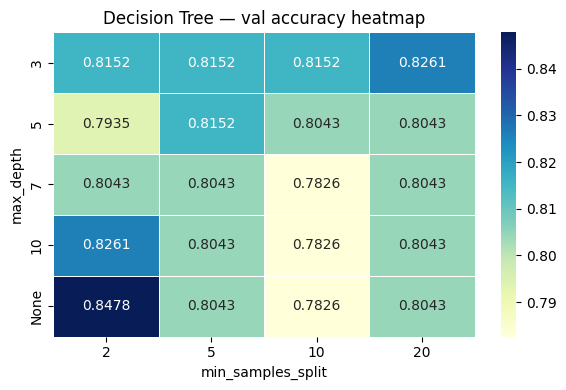


Final Decision Tree Test Accuracy: 0.7935


In [25]:
# Entropy Function
def entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-10))  # 1e-10 avoids log(0)

# IG Calculation
def information_gain(y_parent, y_left, y_right):
    n = len(y_parent)
    n_l, n_r = len(y_left), len(y_right)
    weighted_child_entropy = (n_l / n) * entropy(y_left) + \
                             (n_r / n) * entropy(y_right)
    return entropy(y_parent) - weighted_child_entropy

def best_split(X, y, min_samples_split):
    best_ig        = -1
    best_feature   = None
    best_threshold = None

    n_features = X.shape[1]

    for feature in range(n_features):
        # Use midpoints between consecutive sorted unique values as thresholds
        thresholds = np.unique(X[:, feature])
        thresholds = (thresholds[:-1] + thresholds[1:]) / 2  # midpoints

        for threshold in thresholds:
            left_mask  = X[:, feature] <= threshold
            right_mask = ~left_mask

            y_left, y_right = y[left_mask], y[right_mask]

            # Skip if a child has fewer than min_samples_split samples
            if len(y_left) < min_samples_split or len(y_right) < min_samples_split:
                continue

            ig = information_gain(y, y_left, y_right)

            if ig > best_ig:
                best_ig        = ig
                best_feature   = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_ig

# Node of the decision tree with its corresponding IG value
class Node:
    def __init__(self,
                 feature=None, threshold=None,   # split info (internal node)
                 left=None,    right=None,        # children
                 value=None):                     # leaf prediction
        self.feature   = feature # feature used for split
        self.threshold = threshold # value used for traversing the tree
        self.left      = left
        self.right     = right
        self.value     = value  # not None only for leaf nodes

    def is_leaf(self):
        return self.value is not None

# Decision Tree object : Constructor and functions.
class Decision_Tree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth         = max_depth # the depth that the tree can actually reach
        self.min_samples_split = min_samples_split # the minimum number of samples accepted in a split with impurity
        self.root              = None

    #  Training
    def fit(self, X, y):
        # Starting the first split and moving recursively down the tree
        self.root = self._build(X, y, depth=0)

    def _build(self, X, y, depth):
        n_samples  = len(y)
        n_classes  = len(np.unique(y))

        # Stopping criteria (leaf conditions)
        # maximum depth reached if exist
        # pure node (n_class = 1)
        # number of samples on a node
        if (n_classes == 1 or n_samples < self.min_samples_split or (self.max_depth is not None and depth >= self.max_depth)):
            return Node(value=self._majority_class(y))

        # Finding best split based IG
        feature, threshold, ig = best_split(X, y, self.min_samples_split)

        # No valid split found, then make it leaf (a fallout plan)
        if feature is None or ig <= 0:
            return Node(value=self._majority_class(y))

        # Recurse on both left & right current nodes
        left_mask  = X[:, feature] <= threshold
        right_mask = ~left_mask

        # passing depth parameter to prevent moving past maximum depth 
        left_child  = self._build(X[left_mask],  y[left_mask],  depth + 1)
        right_child = self._build(X[right_mask], y[right_mask], depth + 1)


        return Node(feature=feature, threshold=threshold,
                    left=left_child, right=right_child)

    def _majority_class(self, y):
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]

    # Predicting a given sample by traversing the tree
    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])


    def _traverse(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left)
        return self._traverse(x, node.right)

# Hyperparameter tuning on validation set

# maximum depth and minimum number of samples are hyperparameters
max_depth_length      = [3, 5, 7, 10, None]
min_samples_length    = [2, 5, 10, 20]

best_val_acc   = 0
best_params    = {}
results        = []

for md in max_depth_length:
    for ms in min_samples_length:
        tree = Decision_Tree(max_depth=md, min_samples_split=ms)
        tree.fit(X_train, y_train)

        val_preds = tree.predict(X_val)
        val_acc   = np.mean(val_preds == y_val)

        results.append({'max_depth': md, 'min_samples_split': ms,
                        'val_accuracy': round(val_acc, 4)})

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_params  = {'max_depth': md, 'min_samples_split': ms}

# Print tuning results
print("Hyperparameter Tuning Results:")
print(f"{'max_depth':<12} {'min_samples_split':<20} {'val_accuracy':<12}")
print("-" * 44)
for r in results:
    print(f"{str(r['max_depth']):<12} {r['min_samples_split']:<20} {r['val_accuracy']:<12}")

print(f"\nBest Params : {best_params}")
print(f"Best Val Acc: {best_val_acc:.4f}")


depths_str = [str(d) if d is not None else 'None' for d in max_depth_length]
mins_str   = [str(m) for m in min_samples_length]

matrix = np.array([[
    next(r['val_accuracy'] for r in results
         if r['max_depth']==d and r['min_samples_split']==m)
    for m in min_samples_length]
    for d in max_depth_length])

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(matrix, annot=True, fmt='.4f', cmap='YlGnBu',
            xticklabels=mins_str, yticklabels=depths_str,
            linewidths=0.5, ax=ax, vmin=matrix.min(), vmax=matrix.max())
ax.set_xlabel('min_samples_split'); ax.set_ylabel('max_depth')
ax.set_title('Decision Tree — val accuracy heatmap')
plt.tight_layout(); plt.show()

# ── 5. Train final model with best hyperparameters ────────────────────────────

best_tree = Decision_Tree(**best_params)
best_tree.fit(X_train, y_train)

test_preds = best_tree.predict(X_test)
test_acc   = np.mean(test_preds == y_test)

print(f"\nFinal Decision Tree Test Accuracy: {test_acc:.4f}")

## Section 5: Bagging Ensemble

Implement a **Bagging (Bootstrap Aggregating) classifier from scratch** using your Decision Tree implementation as the base learner.

Implementation requirements:
- Train an ensemble of decision trees (e.g., 10 or 20 trees), each on a **random bootstrap sample** of the training data (sampling with replacement).
- During prediction, aggregate results using **majority voting** among all trees.
- Use the **validation set** to tune the number of trees or tree depth.
- Train the bagging ensemble on the **training set**.

Bagging Hyperparameter Tuning Results:
n_trees         max_depth    min_samples    val_accuracy
-------------------------------------------------------
10              3            2              0.8152
10              3            5              0.8152
10              3            10             0.8152
10              5            2              0.837
10              5            5              0.8152
10              5            10             0.837
10              10           2              0.8478
10              10           5              0.837
10              10           10             0.8152
10              None         2              0.8152
10              None         5              0.837
10              None         10             0.8152
20              3            2              0.8261
20              3            5              0.8261
20              3            10             0.837
20              5            2              0.8478
20              5            5       

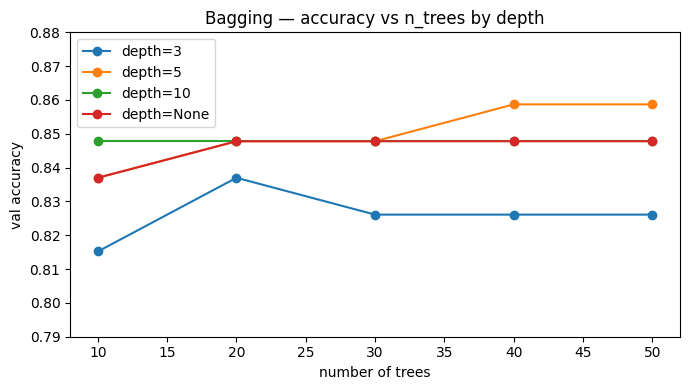


Final Bagging Test Accuracy: 0.8478


In [26]:
# Section 5: Bagging Ensemble
class BaggingClassifier:
    def __init__(self, n_trees=10, max_depth=None, min_samples_split=2, random_state=42):
        self.n_trees      = n_trees
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.random_state      = random_state
        self.trees             = []

    # Training
    def fit(self, X, y):
        self.trees = []
        rng = np.random.RandomState(self.random_state)
        n_samples = X.shape[0]
        for i in range(self.n_trees):
            # Bootstrap sample: sample n_samples WITH replacement
            indices = rng.choice(n_samples, size=n_samples, replace=True)
            X_boot, y_boot = X[indices], y[indices]

            # Train a decision tree on the bootstrap sample
            tree = Decision_Tree(max_depth=self.max_depth,
                                min_samples_split=self.min_samples_split)
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

    # Predicting the value for a sample
    def predict(self, X):
        # Collect predictions from all trees, its shape is (n_trees, n_samples)
        all_preds = np.array([tree.predict(X) for tree in self.trees])

        # Majority vote for each sample
        final_preds = []
        for sample_preds in all_preds.T:                      # iterate over columns
            classes, counts = np.unique(sample_preds, return_counts=True)
            final_preds.append(classes[np.argmax(counts)])

        return np.array(final_preds)


# Hyperparameter Tuning

n_trees_length   = [10, 20, 30, 40, 50] # the number of trees to train on bootstrap 
max_depth_length  = [3, 5, 10, None]
min_samples_length = [2, 5, 10]

best_bag_val_acc = 0
best_bag_params  = {}
bag_results      = []

for n_est in n_trees_length:
    for md in max_depth_length:
        for ms in min_samples_length :
            bag = BaggingClassifier(n_trees=n_est, max_depth=md,
                                    min_samples_split=ms, random_state=42)
            bag.fit(X_train, y_train)
            val_preds = bag.predict(X_val)
            val_acc   = np.mean(val_preds == y_val)

            bag_results.append({'n_trees': n_est, 'max_depth': md,
                                 'min_samples_split': ms,
                                 'val_accuracy': round(val_acc, 4)})

            if val_acc > best_bag_val_acc:
                best_bag_val_acc = val_acc
                best_bag_params  = {'n_trees': n_est, 'max_depth': md,
                                    'min_samples_split': ms}

print("Bagging Hyperparameter Tuning Results:")
print(f"{'n_trees':<15} {'max_depth':<12} {'min_samples':<14} {'val_accuracy'}")
print("-" * 55)
for r in bag_results:
    print(f"{r['n_trees']:<15} {str(r['max_depth']):<12} "
          f"{r['min_samples_split']:<14} {r['val_accuracy']}")

print(f"\nBest Params : {best_bag_params}")
print(f"Best Val Acc: {best_bag_val_acc:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
for md in max_depth_length:
    label = f'depth={md}'
    xs, ys = [], []
    for n in n_trees_length:
        best_for_combo = max(
            (r['val_accuracy'] for r in bag_results
             if r['n_trees']==n and r['max_depth']==md), default=None)
        if best_for_combo: xs.append(n); ys.append(best_for_combo)
    ax.plot(xs, ys, marker='o', label=label)

ax.set_xlabel('number of trees'); ax.set_ylabel('val accuracy')
ax.set_title('Bagging — accuracy vs n_trees by depth')
ax.set_ylim(0.79, 0.88); ax.legend(); plt.tight_layout(); plt.show()

# ── Train final Bagging model ─────────────────────────────────────────────────

best_bag = BaggingClassifier(**best_bag_params, random_state=42)
best_bag.fit(X_train, y_train)

bag_test_preds = best_bag.predict(X_test)
bag_test_acc   = np.mean(bag_test_preds == y_test)
print(f"\nFinal Bagging Test Accuracy: {bag_test_acc:.4f}")

## Section 6: AdaBoost Ensemble

Implement the **AdaBoost algorithm from scratch** using decision stumps (depth-1 trees) or shallow decision trees as weak learners.

Implementation requirements:
- Use your Decision Tree implementation restricted to **depth 1 (stump)** or a few levels as the weak learner.
- At each boosting round:
  1. Fit a weak learner on the **weighted** training data.
  2. Compute the **weighted error** $\epsilon_t$.
  3. Compute the learner weight $\alpha_t = \frac{1}{2} \ln\left(\frac{1 - \epsilon_t}{\epsilon_t}\right)$.
  4. **Update sample weights**: increase weights for misclassified samples, decrease for correctly classified.
  5. Normalize the weights.
- Use a reasonable number of boosting rounds (e.g., **50 rounds**) or tune using the validation set.
- Final prediction: $H(x) = \text{sign}\left(\sum_t \alpha_t h_t(x)\right)$

AdaBoost Hyperparameter Tuning Results:
n_stumps        max_depth    val_accuracy
----------------------------------------
10              1            0.8043
10              2            0.837
10              3            0.8587
20              1            0.8043
20              2            0.8587
20              3            0.837
30              1            0.8152
30              2            0.8478
30              3            0.8478
40              1            0.8152
40              2            0.8696
40              3            0.8587
50              1            0.8587
50              2            0.8261
50              3            0.8478
75              1            0.8152
75              2            0.7935
75              3            0.8587
100             1            0.8261
100             2            0.8696
100             3            0.8478

Best Params : {'n_stumps': 40, 'max_depth': 2}
Best Val Acc: 0.8696


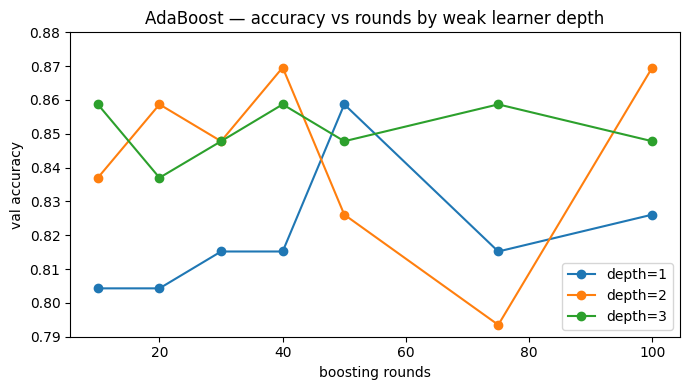


Final AdaBoost Test Accuracy: 0.8641


In [27]:
class AdaBoostClassifier:
    def __init__(self, n_stumps=50, max_depth=1, min_samples_split=2):
        self.n_stumps      = n_stumps
        self.max_depth         = max_depth # if 1 we're using decision stump, o.s. decision tree
        self.min_samples_split = min_samples_split
        self.A_ts            = []
        self.learners          = []

    def fit(self, X, y):
        n_samples     = X.shape[0]
        self.A_ts   = []
        self.learners = []
        self.classes_ = np.unique(y)

        # initial sample weights (w_i = 1/N)
        weights = np.ones(n_samples) / n_samples

        for t in range(self.n_stumps):

            # 1. Train weak learner on weighted resample
            indices = np.random.choice(n_samples, size=n_samples,
                                       p=weights, replace=True)
            X_w, y_w = X[indices], y[indices]

            stump = Decision_Tree(max_depth=self.max_depth,
                                 min_samples_split=self.min_samples_split)
            stump.fit(X_w, y_w)

            # 2. Predict on full training set
            preds = stump.predict(X)

            # 3. Compute weighted error ε_t
            misclassified = (preds != y)
            e_t = np.dot(weights, misclassified.astype(float))

            # Skip if worse than random or perfect
            if e_t >= 0.5 or e_t == 0:
                continue

            # 4. Compute classifier weight α_t
            A_t = 0.5 * np.log((1 - e_t) / e_t)

            # ── 5. Update weights using the simplified rule ───────────────────
            #   Misclassified: w_new = w_old / (2 * e_t)
            #   Correct:       w_new = w_old / (2 * (1 - e_t))
            # This is mathematically equivalent to the exp(±α) rule but
            # skips the normalization step since the weights already sum to 1
            # after this update (built into the denominators).

            new_weights = np.where(
                misclassified,
                weights / (2 * e_t),          # misclassified → increase weight
                weights / (2 * (1 - e_t))     # correct       → decrease weight
            )

            # No explicit normalization needed — the rule guarantees sum = 1
            # but we add a safety normalization to handle floating point drift
            weights = new_weights / np.sum(new_weights)

            self.A_ts.append(A_t)
            self.learners.append(stump)

    def predict(self, X):
        weighted_sum = np.zeros(X.shape[0])

        for A_t, stump in zip(self.A_ts, self.learners):
            preds = stump.predict(X)
            # Map to {-1, +1}: class_0 → -1, class_1 → +1
            preds_signed = np.where(preds == self.classes_[0], -1, 1)
            weighted_sum += A_t * preds_signed

        return np.where(weighted_sum >= 0, self.classes_[1], self.classes_[0])

# Hyperparameter Tuning 

n_rounds_lengths  = [10, 20, 30, 40, 50, 75, 100]
depths_ada = [1, 2, 3] 

best_ada_val_acc = 0
best_ada_params  = {}
ada_results      = []

for n_rounds in n_rounds_lengths:
    for depth in depths_ada:
        ada = AdaBoostClassifier(n_stumps=n_rounds, max_depth=depth)
        ada.fit(X_train, y_train)
        val_preds = ada.predict(X_val)
        val_acc   = np.mean(val_preds == y_val)

        ada_results.append({'n_stumps': n_rounds, 'max_depth': depth,
                             'val_accuracy': round(val_acc, 4)})

        if val_acc > best_ada_val_acc:
            best_ada_val_acc = val_acc
            best_ada_params  = {'n_stumps': n_rounds, 'max_depth': depth}

print("AdaBoost Hyperparameter Tuning Results:")
print(f"{'n_stumps':<15} {'max_depth':<12} {'val_accuracy'}")
print("-" * 40)
for r in ada_results:
    print(f"{r['n_stumps']:<15} {r['max_depth']:<12} {r['val_accuracy']}")

print(f"\nBest Params : {best_ada_params}")
print(f"Best Val Acc: {best_ada_val_acc:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
for depth in depths_ada:
    xs = [r['n_stumps'] for r in ada_results if r['max_depth']==depth]
    ys = [r['val_accuracy'] for r in ada_results if r['max_depth']==depth]
    ax.plot(xs, ys, marker='o', label=f'depth={depth}')

ax.set_xlabel('boosting rounds'); ax.set_ylabel('val accuracy')
ax.set_title('AdaBoost — accuracy vs rounds by weak learner depth')
ax.set_ylim(0.79, 0.88); ax.legend(); plt.tight_layout(); plt.show()

# Train final AdaBoost model

best_ada = AdaBoostClassifier(**best_ada_params)
best_ada.fit(X_train, y_train)

ada_test_preds = best_ada.predict(X_test)
ada_test_acc   = np.mean(ada_test_preds == y_test)
print(f"\nFinal AdaBoost Test Accuracy: {ada_test_acc:.4f}")

## Section 7: Evaluation

Evaluate each trained model on the **test set** using the following metrics:

- **Accuracy:** Proportion of correctly classified test samples.
- **F1-Score:** Harmonic mean of precision and recall — especially important for binary classification with potential class imbalance.
- **Confusion Matrix:** Visualize the matrix for each model to identify misclassification patterns and the most confusing classes.

Summarize accuracy and F1-score for all models in a comparison table.

Model                Accuracy     F1-Score
Decision Tree        0.7935       0.8081
Bagging              0.8478       0.8614
AdaBoost             0.8641       0.8744


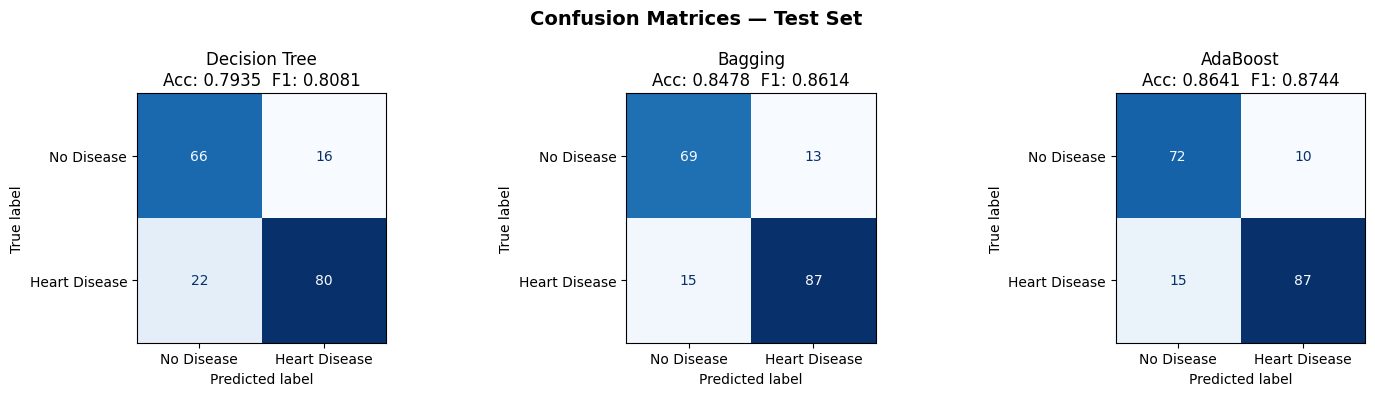

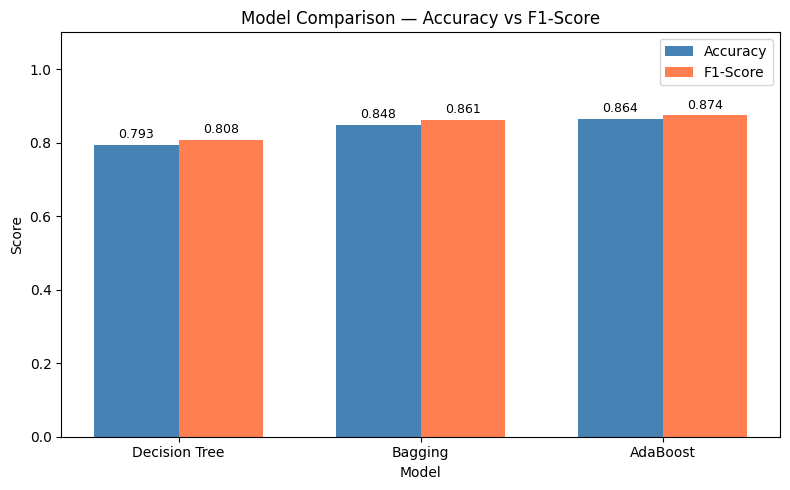


Per-Class F1 Breakdown:
Model                F1 (No Disease)      F1 (Heart Disease)
------------------------------------------------------------
Decision Tree        0.7765               0.8081
Bagging              0.8313               0.8614
AdaBoost             0.8521               0.8744


In [28]:
# ── Helper: compute and display all metrics for one model ─────────────────────

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='binary')
    cm  = confusion_matrix(y_true, y_pred)
    return {'Model': name, 'Accuracy': round(acc, 4), 'F1-Score': round(f1, 4), 'CM': cm}


# ── Collect results for all three models ──────────────────────────────────────

dt_results  = evaluate_model("Decision Tree", y_test, test_preds)
bag_results_eval = evaluate_model("Bagging",       y_test, bag_test_preds)
ada_results_eval = evaluate_model("AdaBoost",      y_test, ada_test_preds)

all_results = [dt_results, bag_results_eval, ada_results_eval]


# ── 1. Summary Table ──────────────────────────────────────────────────────────

print("=" * 45)
print(f"{'Model':<20} {'Accuracy':<12} {'F1-Score'}")
print("=" * 45)
for r in all_results:
    print(f"{r['Model']:<20} {r['Accuracy']:<12} {r['F1-Score']}")
print("=" * 45)


# ── 2. Confusion Matrices ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight='bold')

for ax, r in zip(axes, all_results):
    disp = ConfusionMatrixDisplay(confusion_matrix=r['CM'],
                                   display_labels=['No Disease', 'Heart Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['Model']}\nAcc: {r['Accuracy']}  F1: {r['F1-Score']}")

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 3. Bar chart comparison ───────────────────────────────────────────────────

models     = [r['Model']    for r in all_results]
accuracies = [r['Accuracy'] for r in all_results]
f1_scores  = [r['F1-Score'] for r in all_results]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1-Score',  color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy vs F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend()

# Annotate bar values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 4. Per-class breakdown ────────────────────────────────────────────────────

print("\nPer-Class F1 Breakdown:")
print(f"{'Model':<20} {'F1 (No Disease)':<20} {'F1 (Heart Disease)'}")
print("-" * 60)
for r in all_results:
    f1_per_class = f1_score(y_test,
                            best_tree.predict(X_test)
                            if r['Model'] == 'Decision Tree'
                            else (best_bag.predict(X_test)
                                  if r['Model'] == 'Bagging'
                                  else best_ada.predict(X_test)),
                            average=None)
    print(f"{r['Model']:<20} {f1_per_class[0]:<20.4f} {f1_per_class[1]:.4f}")

## Section 8: Analysis and Comparison

After obtaining all results, analyze and compare the performance of the different classifiers. Address the following discussion points:

1. **Best performing model:** Which model achieved the highest accuracy and F1-score? Why do you think it outperformed the others?
2. **Decision Tree vs. Ensemble Methods:** Compare the single Decision Tree to the Bagging and AdaBoost ensembles. How do the ensemble methods improve (or not) over the base learner?
3. **Confusion Matrix Insights:** Based on the confusion matrices, are there specific misclassification patterns? Which class is more frequently confused, and what might explain this?
4. **Bagging vs. AdaBoost:** How do the two ensemble strategies differ in their approach and in their final results on this dataset?

*Write your analysis here.*